In [1]:

# === 0. Basic Setup ===
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
import xgboost as xgb
import shap
import geopandas as gpd
from sklearn.cluster import MiniBatchKMeans

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import numpy as np




# === 1. Data Loading ===
data_path =  r'C:\Users\astra\Downloads\dataset2_large_scale_yield\dataset2_large_scale_yield'
parquet_files = [f for f in os.listdir(data_path) if f.endswith(".parquet")]
df_list = [pd.read_parquet(os.path.join(data_path, f)) for f in parquet_files]
df = pd.concat(df_list, ignore_index=True)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# === 2. Preprocessing + Aggregation ===
use_cols = ["SiteName","Year","Yield","Biomass","GreenLeafN","CanopyHeight",
            "Radn","Rain","MaxT","MinT","Latitude","Longitude"]
df = df[use_cols].copy()

agg = {
    "Yield": "mean",
    "Biomass": "mean",
    "GreenLeafN": "mean",
    "CanopyHeight": "mean",
    "Radn": "sum",
    "Rain": "sum",
    "MaxT": "mean",
    "MinT": "mean",
    "Latitude": "mean",
    "Longitude": "mean",
}
season = df.groupby(["SiteName", "Year"], as_index=False).agg(agg)
season.rename(columns={"Radn": "TotalRadn", "Rain": "TotalRain", "MaxT": "MeanMaxT", "MinT": "MeanMinT"}, inplace=True)



In [2]:
print(season.head())

      SiteName    Year      Yield     Biomass  GreenLeafN  CanopyHeight  \
0  Badgingarra  2001.0  61.991824  409.947168    2.414717    640.714659   
1  Badgingarra  2002.0  64.669633  436.183707    2.478629    645.639957   
2  Badgingarra  2003.0  57.743842  383.912058    2.028821    636.105500   
3  Badgingarra  2004.0  59.445381  403.093821    2.226363    629.794406   
4  Badgingarra  2005.0  58.398881  370.074595    1.759163    650.997190   

       TotalRadn     TotalRain   MeanMaxT  MeanMinT  Latitude  Longitude  
0  236783.199904  31247.900022  20.261821  7.866664    -30.34     115.54  
1  239610.399147  30477.500021  20.286736  8.379117    -30.34     115.54  
2  244401.700509  37529.699954  19.856978  8.347612    -30.34     115.54  
3  242962.700354  26013.900075  19.782300  8.403334    -30.34     115.54  
4  246815.100083  39141.200221  19.026592  7.532248    -30.34     115.54  


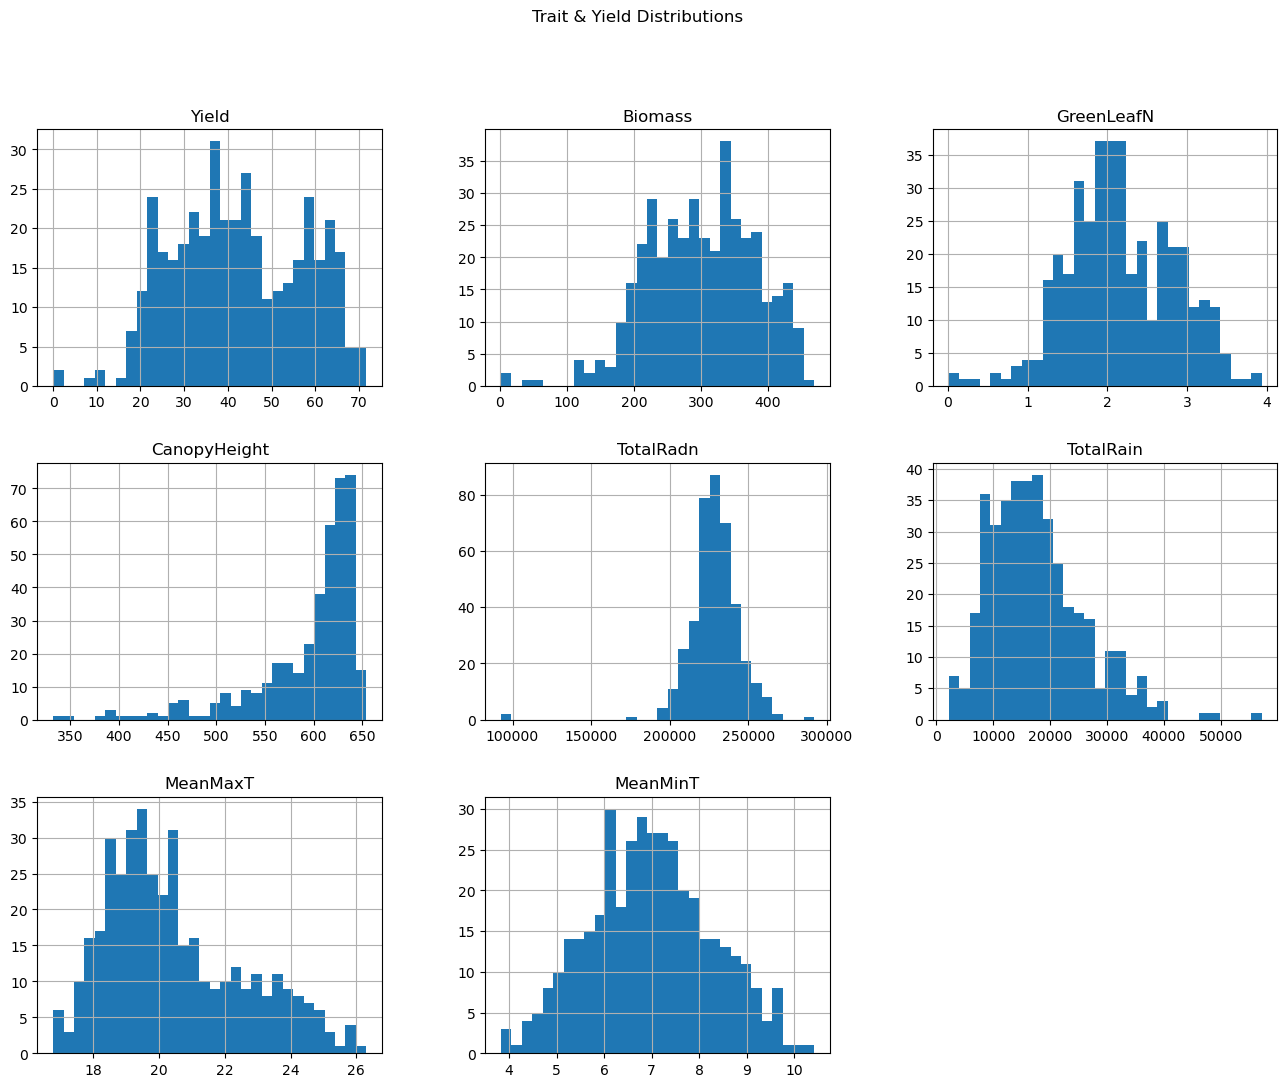

In [3]:

# === 3. EDA ===
traits = ["Yield", "Biomass", "GreenLeafN", "CanopyHeight", "TotalRadn", "TotalRain", "MeanMaxT", "MeanMinT"]

# Distribution plots
season[traits].hist(bins=30, figsize=(16, 12))
plt.suptitle("Trait & Yield Distributions")
plt.show()


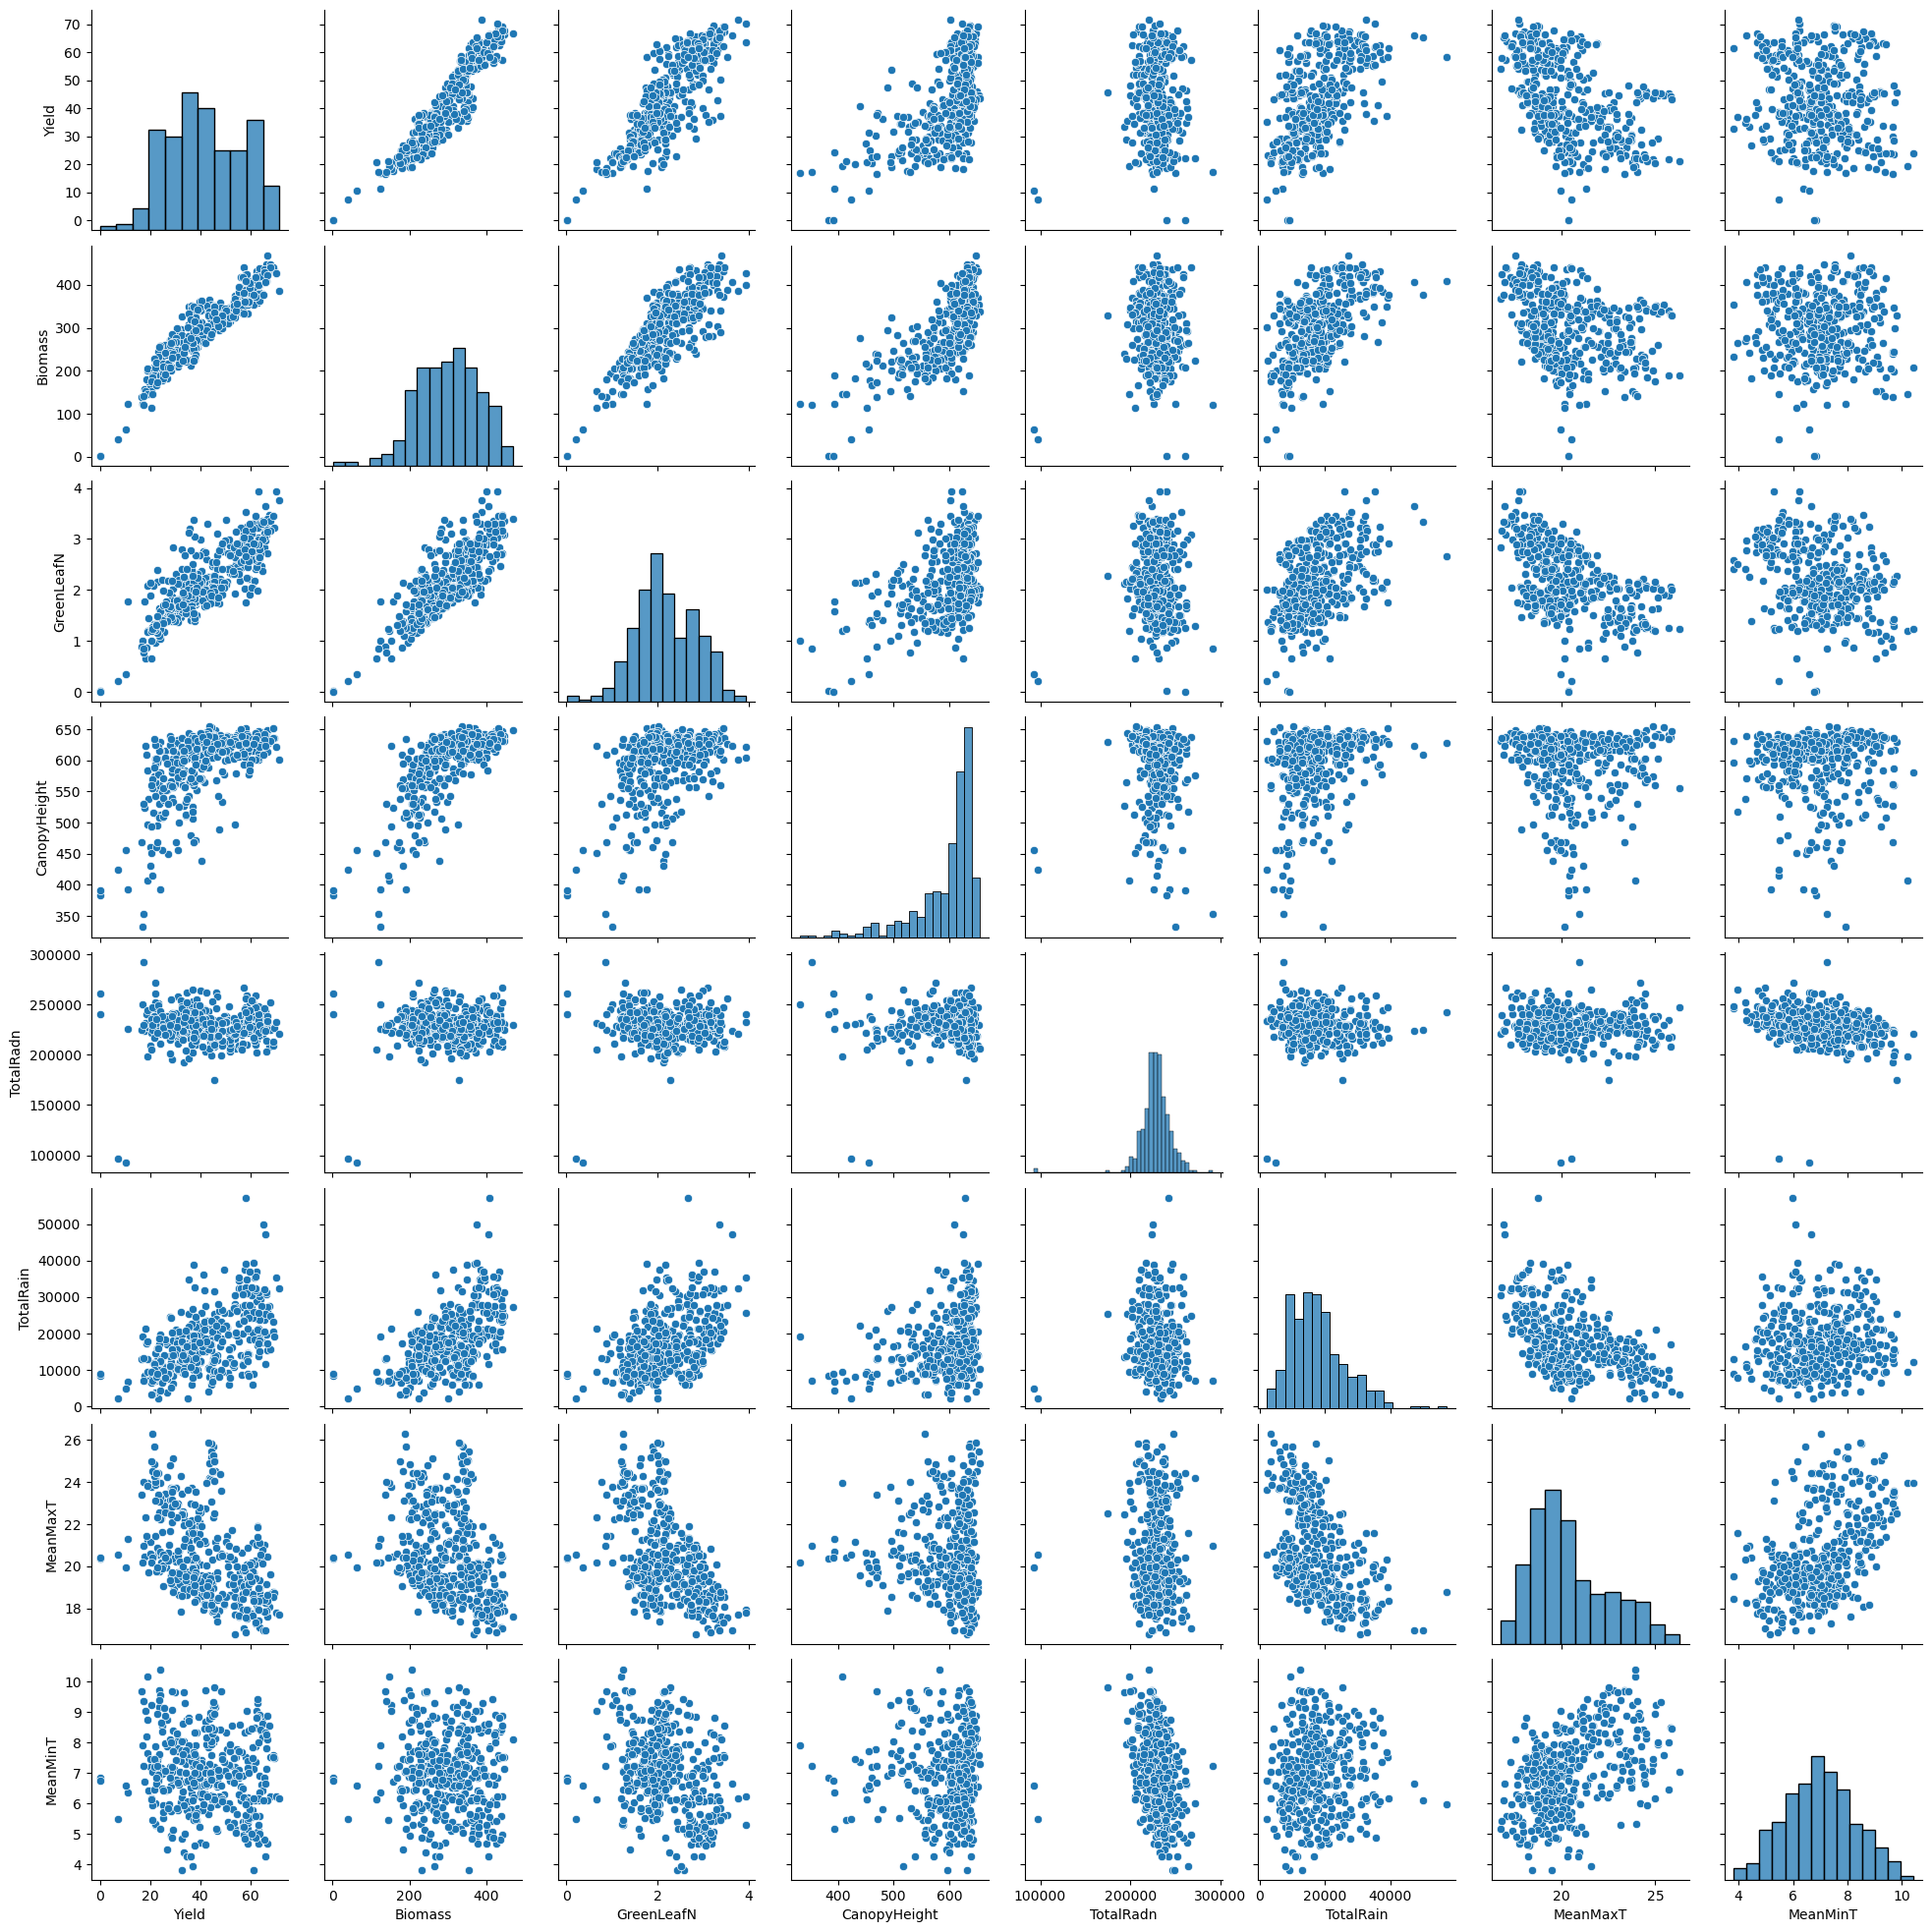

In [4]:
# Pairplot
sns.pairplot(season[traits])
plt.show()


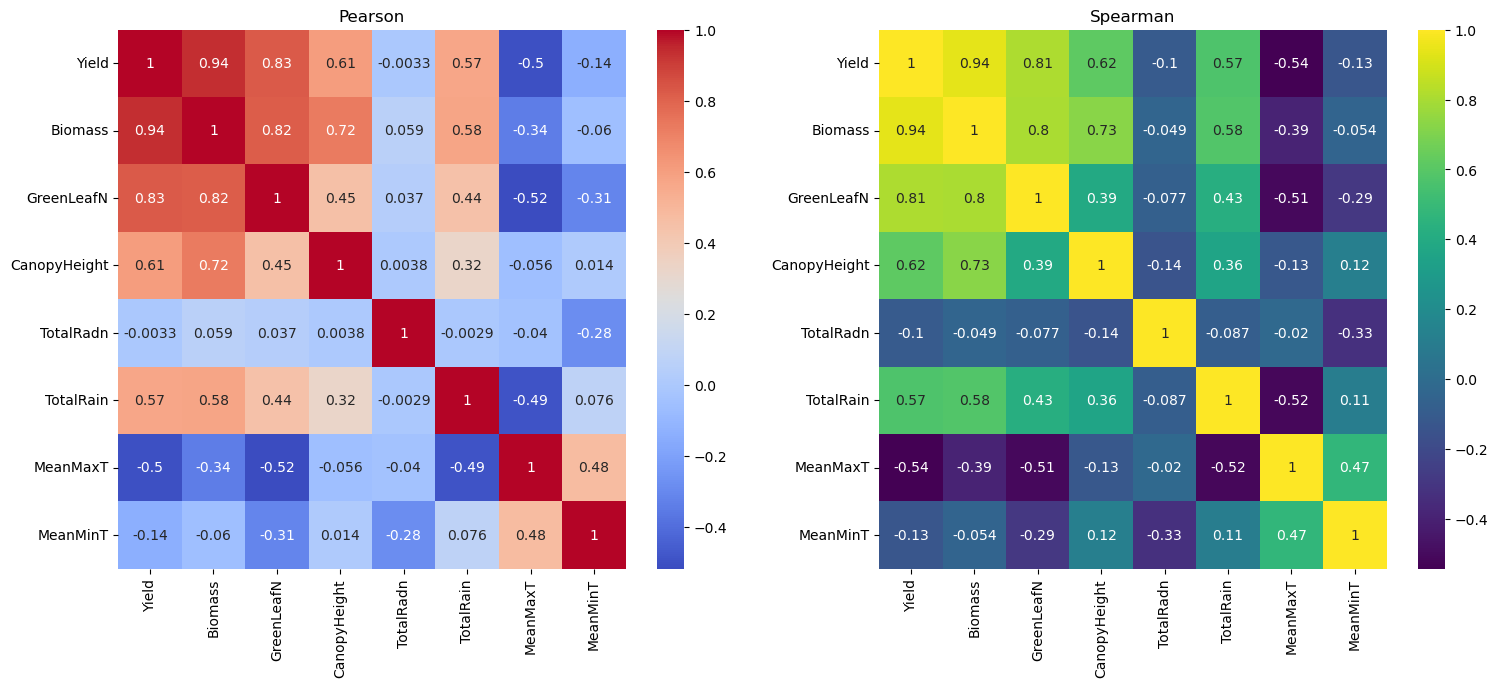

In [5]:
# Correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(season[traits].corr("pearson"), annot=True, ax=axes[0], cmap="coolwarm")
axes[0].set_title("Pearson")
sns.heatmap(season[traits].corr("spearman"), annot=True, ax=axes[1], cmap="viridis")
axes[1].set_title("Spearman")
plt.show()

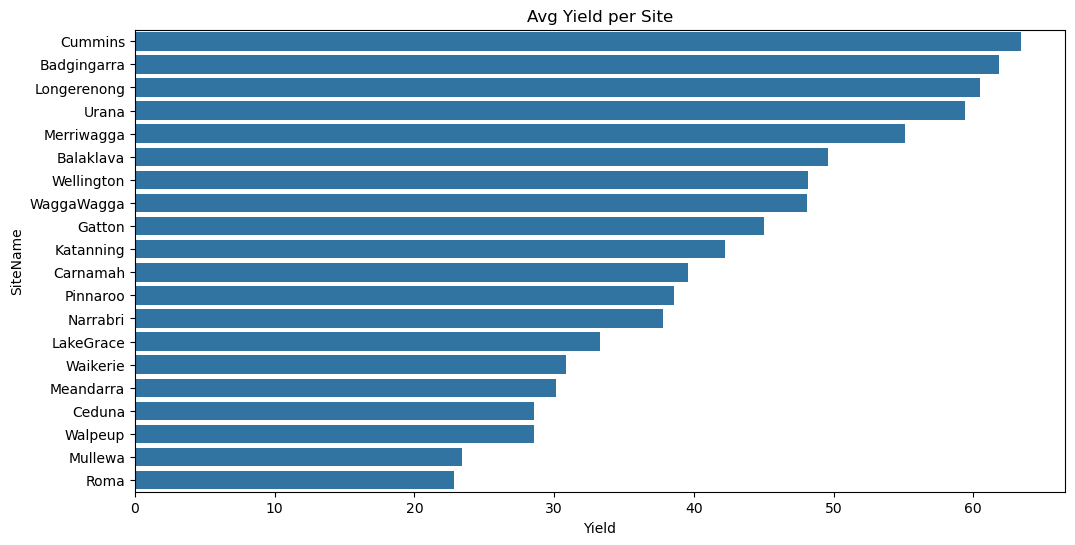

In [6]:
# Group by Site
site_summary = season.groupby("SiteName")[traits].mean().sort_values("Yield", ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=site_summary, x="Yield", y="SiteName")
plt.title("Avg Yield per Site")
plt.show()

In [7]:
# === 4. Modeling Setup ===
features = ["Biomass", "GreenLeafN", "CanopyHeight", "TotalRadn", "TotalRain", "MeanMaxT", "MeanMinT"]
X = season[features]
y = season["Yield"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
# Custom RMSE function
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Scoring dictionary
scorers = {
    "RMSE": make_scorer(rmse, greater_is_better=False),  # negative for sklearn
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "R2": make_scorer(r2_score)
}

# Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42),
    "XGBoost": XGBRegressor(objective="reg:squarederror", max_depth=8, n_estimators=300, subsample=0.8, colsample_bytree=0.9, random_state=42),
    "MLP": Pipeline([
        ("scale", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, early_stopping=True, random_state=42))
    ])
}

# Run CV on each model
for name, model in models.items():
    print(f"\n{name}:")
    for metric, scorer in scorers.items():
        score = cross_val_score(model, X, y, cv=kf, scoring=scorer)
        mean_score = -np.mean(score) if metric in ['RMSE', 'MAE'] else np.mean(score)
        print(f"{metric}: {mean_score:.4f}")



Random Forest:
RMSE: 3.5951
MAE: 2.6032
R2: 0.9384

XGBoost:
RMSE: 3.8878
MAE: 2.8079
R2: 0.9288

MLP:
RMSE: 3.9058
MAE: 2.9587
R2: 0.9259


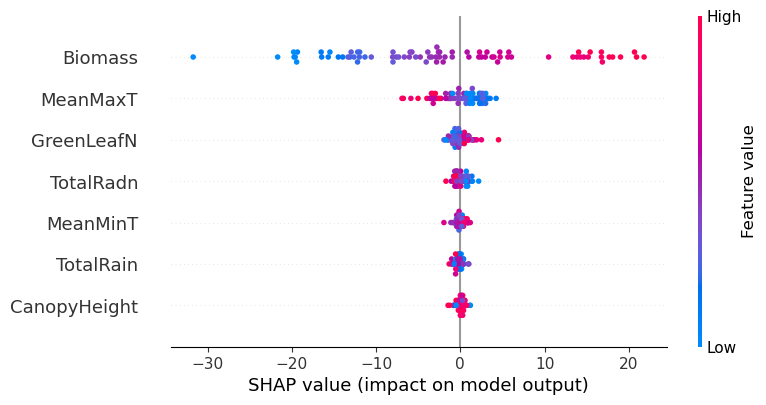

In [9]:
# Fit XGB for SHAP
xgb_model = models['XGBoost']
xgb_model.fit(X_tr, y_tr)

explainer = shap.Explainer(xgb_model)
X_shap = X_te.sample(n=min(1000, len(X_te)), random_state=42)
shap_values = explainer(X_shap)

# Beeswarm
shap.plots.beeswarm(shap_values)

In [10]:
# === 6. SHAP Pairwise Interactions ===
shap_interactions = explainer.shap_interaction_values(X_shap)
interaction_matrix = np.abs(shap_interactions).mean(axis=0)
interaction_pairs = []

for i in range(len(features)):
    for j in range(i+1, len(features)):
        interaction_pairs.append({
            "Feature 1": features[i],
            "Feature 2": features[j],
            "Interaction Strength": interaction_matrix[i][j]
        })

interactions_df = pd.DataFrame(interaction_pairs).sort_values("Interaction Strength", ascending=False)
print("\nTop SHAP Pairwise Interactions:\n", interactions_df.head(10))


Top SHAP Pairwise Interactions:
      Feature 1     Feature 2  Interaction Strength
4      Biomass      MeanMaxT              0.688601
0      Biomass    GreenLeafN              0.580137
3      Biomass     TotalRain              0.232441
9   GreenLeafN      MeanMaxT              0.210277
2      Biomass     TotalRadn              0.206431
1      Biomass  CanopyHeight              0.202071
5      Biomass      MeanMinT              0.174592
10  GreenLeafN      MeanMinT              0.146098
16   TotalRadn      MeanMaxT              0.122027
8   GreenLeafN     TotalRain              0.110783



Agro-Climatic Zone Summary:
   ClimateZone  TotalRain  MeanMaxT  MeanMinT  TotalRadn
0  Cool-Humid   17869.17     20.34      6.96  228727.85
1   Temperate    9471.83     25.54      8.05  224541.79


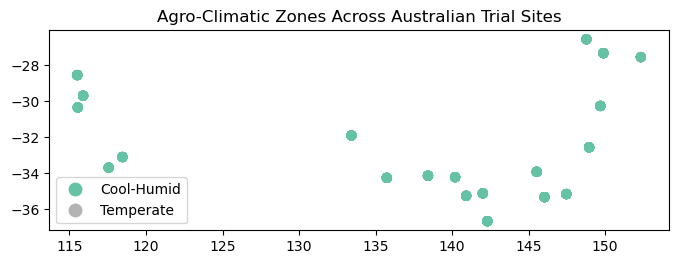


=== SHAP Interactions for Zone: Cool-Humid ===
    Feature 1   Feature 2  Interaction Strength
4     Biomass    MeanMaxT              0.659695
0     Biomass  GreenLeafN              0.582979
3     Biomass   TotalRain              0.237398
2     Biomass   TotalRadn              0.221285
9  GreenLeafN    MeanMaxT              0.207414

=== SHAP Interactions for Zone: Temperate ===
     Feature 1   Feature 2  Interaction Strength
4      Biomass    MeanMaxT              1.298788
0      Biomass  GreenLeafN              0.582768
10  GreenLeafN    MeanMinT              0.353796
3      Biomass   TotalRain              0.254345
20    MeanMaxT    MeanMinT              0.215166

=== Top 3 Feature Pairings per Agro-Climatic Zone ===

  ClimateZone   Feature 1   Feature 2  Interaction Strength
0  Cool-Humid     Biomass    MeanMaxT              0.659695
1  Cool-Humid     Biomass  GreenLeafN              0.582979
2  Cool-Humid     Biomass   TotalRain              0.237398
3   Temperate     Biomass  

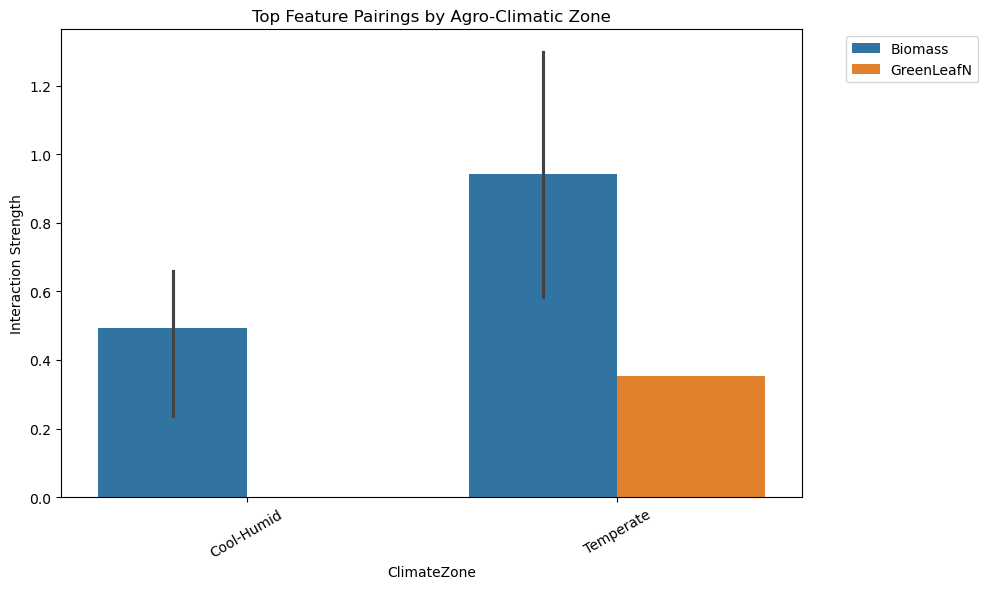

In [11]:
# ===============================================================

def classify_zone(row):
    """Classify trial sites into agro-climatic zones based on AUS thresholds"""
    if row["TotalRain"] < 300 and row["MeanMaxT"] > 30:
        return "Hot-Dry"
    elif row["TotalRain"] < 500:
        return "Warm-Semi-arid"
    elif row["TotalRain"] > 700 and row["MeanMaxT"] > 27:
        return "Tropical"
    elif row["TotalRain"] > 600 and row["MeanMaxT"] < 25:
        return "Cool-Humid"
    else:
        return "Temperate"

# Apply to season-level dataset
season["ClimateZone"] = season.apply(classify_zone, axis=1)

# Quick summary
climate_summary = (
    season.groupby("ClimateZone")[["TotalRain","MeanMaxT","MeanMinT","TotalRadn"]]
    .mean()
    .round(2)
    .reset_index()
)
print("\nAgro-Climatic Zone Summary:\n", climate_summary)

# Plot map of trial sites with assigned zones
import geopandas as gpd
gdf = gpd.GeoDataFrame(
    season,
    geometry=gpd.points_from_xy(season["Longitude"], season["Latitude"]),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(8,6))
gdf.plot(column="ClimateZone", ax=ax, legend=True, cmap="Set2", markersize=40)
plt.title("Agro-Climatic Zones Across Australian Trial Sites")
plt.show()


# ===============================================================
# 2. SHAP Feature Importances + Pairwise Interactions per Zone
# ===============================================================

import shap

# Use the trained XGBRegressor model (already fitted in notebook)
explainer = shap.TreeExplainer(xgb_model)

zone_interactions = {}

for zone in season["ClimateZone"].unique():
    print(f"\n=== SHAP Interactions for Zone: {zone} ===")

    # Subset test data for this zone
    zone_idx = season["ClimateZone"] == zone
    X_zone = season.loc[zone_idx, features]

    if X_zone.shape[0] < 5:
        print(f"  Skipping {zone} (too few samples)")
        continue

    # SHAP values for subset
    shap_values = explainer.shap_values(X_zone)

    # Pairwise interaction matrix
    shap_interactions = explainer.shap_interaction_values(X_zone)
    interaction_matrix = np.abs(shap_interactions).mean(axis=0)

    # Rank top interactions
    interaction_pairs = []
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            interaction_pairs.append({
                "Feature 1": features[i],
                "Feature 2": features[j],
                "Interaction Strength": interaction_matrix[i][j]
            })
    df_pairs = pd.DataFrame(interaction_pairs).sort_values("Interaction Strength", ascending=False)

    # Save results
    zone_interactions[zone] = df_pairs

    print(df_pairs.head(5))  # show top 5 per zone

# Example visualization: Top interaction for Tropical zone
if "Tropical" in zone_interactions:
    top1 = zone_interactions["Tropical"].iloc[0]
    shap.dependence_plot(
        (top1["Feature 1"], top1["Feature 2"]),
        shap_interactions,
        X_zone,
        interaction_index=top1["Feature 2"]
    )

# ===============================================================
# 3. Summarize Top Feature Pairings by Climate Zone
# ===============================================================

summary_rows = []
for zone, df_pairs in zone_interactions.items():
    top3 = df_pairs.head(3).copy()
    top3["ClimateZone"] = zone
    summary_rows.append(top3)

zone_summary_df = pd.concat(summary_rows, ignore_index=True)

# Reorder columns
zone_summary_df = zone_summary_df[["ClimateZone", "Feature 1", "Feature 2", "Interaction Strength"]]

print("\n=== Top 3 Feature Pairings per Agro-Climatic Zone ===\n")
print(zone_summary_df)

# Save to CSV (optional, for report or PowerPoint use)
zone_summary_df.to_csv("top_feature_pairings_by_zone.csv", index=False)

# Quick visualization: heatmap-like plot of interactions by zone
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(
    data=zone_summary_df,
    x="ClimateZone", y="Interaction Strength",
    hue="Feature 1"
)
plt.title("Top Feature Pairings by Agro-Climatic Zone")
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
